### And welcome to Week 4, Day 3 - more LangGraph..

In [1]:
!uv pip install -U langgraph langchain-core langchain-groq

Using Python 3.12.3 environment at: /home/crc/projects/agents/.venv
Resolved 35 packages in 211ms                                        
Audited 35 packages in 0.52ms


In [1]:
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_groq import ChatGroq
from typing import TypedDict


In [2]:
# Our favorite first step! Crew was doing this for us, by the way.
load_dotenv(override=True)


True

### First, let's go set up LangSmith!

https://langsmith.com

### Next, here is a useful function in LangChain community:

In [3]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper = GoogleSerperAPIWrapper()
serper.run("What is the capital of France?")

"Paris is the capital and largest city of France, with an estimated city population of 2.04 million in an area of 105.4 km2 (40.7 sq mi), and a metropolitan ... Paris, city and capital of France, located along the Seine River, in the north-central part of the country. Paris is one of the world's most important and ... Paris is the capital and most populous city of France. Situated on the Seine River, in the north of the country, it is in the centre of the Île-de-France ... PARIS it is the capital and largest city of France. Located on the Seine in the country's north, it is a major cultural and political centre of ... Paris is the city of romance par excellence, the fashion capital and the best example of French art de vivre. Its capital, largest city and main cultural and economic centre is Paris. Metropolitan France was settled during the Iron Age by Celtic tribes known as Gauls ... Paris became capital of France because France evolved from a federation of counties to a kingdom, wher

### Now here is a LangChain wrapper class for converting functions into Tools

In [5]:
!uv pip install -U langchain langchain-community langchain-core

Using Python 3.12.3 environment at: /home/crc/projects/agents/.venv
Resolved 53 packages in 569ms                                        ⠋ Resolving dependencies...                                                     
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/109.12 KiB          
⠙ Preparing packages... (0/1)------------------- 16.00 KiB/109.12 KiB        
⠙ Preparing packages... (0/1)------------------- 32.00 KiB/109.12 KiB        
⠙ Preparing packages... (0/1)2m----------------- 48.00 KiB/109.12 KiB        
⠙ Preparing packages... (0/1)0m------------- 64.00 KiB/109.12 KiB        
⠙ Preparing packages... (0/1)---------- 80.00 KiB/109.12 KiB        
⠙ Preparing packages... (0/1)---------- 96.00 KiB/109.12 KiB        
⠙ Preparing packages... (0/1)---------- 109.12 KiB/109.12 KiB       
Prepared 1 package in 78ms                                                        
Uninstalled 1 package in 

In [7]:
from langchain_core.tools import Tool
 

tool_search =Tool(
        name="search",
        func=serper.run,
        description="Useful for when you need more information from an online search"
    )



### Now we can try out the tool the langchain way

In [8]:
tool_search.invoke("What is the capital of France?")

'Paris'

### And now let's write a tool ourselves

We'll pick a familiar one

In [9]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

In [10]:
tool_push = Tool(
        name="send_push_notification",
        func=push,
        description="useful for when you want to send a push notification"
    )

tool_push.invoke("Hello, me")

### Back to the Graph from yesterday

One small change - using TypedDict instead of BaseModel for the State object

When we implement tools, we always need to make 2 changes to the code:

1. Changes to provide the tools to OpenAI in json when we make the call

2. Changes to handle the results back: look for the model staying that the finish_reason=="tool_calls" and then retrieve the call, run the function, provide the results.

### Bring them together

In [11]:
tools = [tool_search, tool_push]

In [12]:
# Step 1: Define the State object
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [13]:
# Step 2: Start the Graph Builder with this State class
graph_builder = StateGraph(State)

In [14]:
# This is different:

llm = ChatGroq(model="llama-3.3-70b-versatile") 
llm_with_tools = llm.bind_tools(tools)

In [15]:
# Step 3: Create a Node


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

In [16]:
# Step 4: Create Edges


graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")

# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

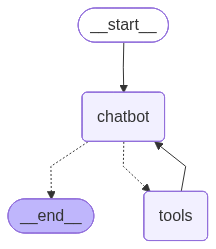

In [17]:
# Step 5: Compile the Graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### That's it! And, let's do this:

In [ ]:
def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/home/crc/projects/agents/.venv/lib/python3.12/site-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crc/projects/agents/.venv/lib/python3.12/site-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crc/projects/agents/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crc/projects/agents/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 1621, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crc/projects/agents/.venv/lib/python3.12/site-packages/gradio/utils.py", line 882, in async_wrapper
    response =

## OK it's time to add Memory!

### BUT WAIT!

We have this whole Graph maintaining the state and appending to the state.

Why isn't this handling memory?

### This is a crucial point for understanding LangGraph

> A super-step can be considered a single iteration over the graph nodes. Nodes that run in parallel are part of the same super-step, while nodes that run sequentially belong to separate super-steps.


One "Super-Step" of the graph represents one invocation of passing messages between agents.

In idomatic LangGraph, you call invoke to run your graph for each super-step; for each interaction.

The reducer handles state updates automatically within one super-step, but not between them.

That is what checkpointing achieves.

In [19]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

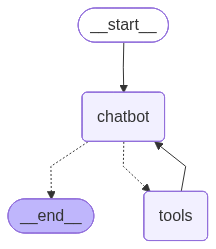

In [20]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatGroq(model="llama-3.3-70b-versatile") 
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='holaa', additional_kwargs={}, response_metadata={}, id='ae86744e-e7c5-48ad-8b85-1c39ca5ae222')]}
{'messages': [HumanMessage(content='holaa', additional_kwargs={}, response_metadata={}, id='ae86744e-e7c5-48ad-8b85-1c39ca5ae222'), AIMessage(content='Hello. Is there something I can help you with?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 307, 'total_tokens': 319, 'completion_time': 0.042901686, 'completion_tokens_details': None, 'prompt_time': 0.018960865, 'prompt_tokens_details': None, 'queue_time': 0.053481816, 'total_time': 0.061862551}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd7b8-9b80-7c00-b61a-016d22a7369c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 307, 'output_tokens': 12, 'total_tokens': 319}), HumanMessa

In [22]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='holaa', additional_kwargs={}, response_metadata={}, id='ae86744e-e7c5-48ad-8b85-1c39ca5ae222'), AIMessage(content='Hello. Is there something I can help you with?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 307, 'total_tokens': 319, 'completion_time': 0.042901686, 'completion_tokens_details': None, 'prompt_time': 0.018960865, 'prompt_tokens_details': None, 'queue_time': 0.053481816, 'total_time': 0.061862551}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd7b8-9b80-7c00-b61a-016d22a7369c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 307, 'output_tokens': 12, 'total_tokens': 319}), HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='460cc6f6-1760-4692-b1ed-64a4c6e31b4f'), AIMess

In [23]:
# Most recent first

list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='holaa', additional_kwargs={}, response_metadata={}, id='ae86744e-e7c5-48ad-8b85-1c39ca5ae222'), AIMessage(content='Hello. Is there something I can help you with?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 307, 'total_tokens': 319, 'completion_time': 0.042901686, 'completion_tokens_details': None, 'prompt_time': 0.018960865, 'prompt_tokens_details': None, 'queue_time': 0.053481816, 'total_time': 0.061862551}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd7b8-9b80-7c00-b61a-016d22a7369c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 307, 'output_tokens': 12, 'total_tokens': 319}), HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='460cc6f6-1760-4692-b1ed-64a4c6e31b4f'), AIMes

### LangGraph gives you tools to set the state back to a prior point in time, to branch off:

```
config = {"configurable": {"thread_id": "1", "checkpoint_id": ...}}
graph.invoke(None, config=config)
```

And this allows you to build stable systems that can be recovered and rerun from any prior checkpoint.

### And now let's store in SQL

### And this is the power of LangGraph.

In [24]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

db_path = "memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
sql_memory = SqliteSaver(conn)

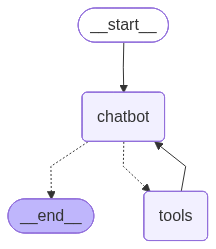

In [25]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatGroq(model="llama-3.3-70b-versatile") 
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=sql_memory)
display(Image(graph.get_graph().draw_mermaid_png()))
 

In [ ]:
config = {"configurable": {"thread_id": "3"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/home/crc/projects/agents/.venv/lib/python3.12/site-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crc/projects/agents/.venv/lib/python3.12/site-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crc/projects/agents/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crc/projects/agents/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 1621, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crc/projects/agents/.venv/lib/python3.12/site-packages/gradio/utils.py", line 882, in async_wrapper
    response =